You need
LANGSMITH_API_KEY (and your LangSmith project name).

*   [LANGSMITH_API_KEY](https://smith.langchain.com/o/dfb4c27f-730c-5be2-a2a4-34df91381a75/settings/apikeys)
*   [LangSmith project name](https://smith.langchain.com/o/dfb4c27f-730c-5be2-a2a4-34df91381a75/projects)



In [1]:
!pip -q install -U langchain langchain-core langgraph langsmith pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 13.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires 

In [2]:
from kaggle_secrets import UserSecretsClient
import os
user_secrets = UserSecretsClient()

# LangSmith
os.environ["LANGSMITH_API_KEY"] = user_secrets.get_secret("langsmith")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] ="langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = user_secrets.get_secret("LANGSMITH_ENDPOINT")

print("Tracing:", os.environ["LANGCHAIN_TRACING_V2"])
print("Project:", os.environ["LANGCHAIN_PROJECT"])


Tracing: true
Project: langgraph


In [3]:
from typing import List, Dict, Any, Optional, TypedDict, Literal
from pydantic import BaseModel, Field
from transformers import pipeline
from langchain_core.messages import HumanMessage, SystemMessage

llm = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.2", 
    temperature=0.2
)

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


# Single Agent

In [4]:
SINGLE_AGENT_SYSTEM = """You are a helpful AI.
Task: Provide a well-reasoned recommendation to the user question.
Rules:
- Make your best effort without browsing the web.
- Be structured:
  Summary
  Pros
  Cons
  Recommendation
  Risks
  Confidence (0-100).
"""

def single_agent_answer(question: str):
    prompt = f"""{SINGLE_AGENT_SYSTEM}

User Question:
{question}

Assistant:
"""

    response = llm(
        prompt,
        max_new_tokens=512,
        do_sample=False,
    )

    return response[0]["generated_text"]

question = "Should a startup use open-source LLMs or closed models in 2026? Consider cost, speed, privacy, and reliability."

print(single_agent_answer(question))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are a helpful AI.
Task: Provide a well-reasoned recommendation to the user question.
Rules:
- Make your best effort without browsing the web.
- Be structured:
  Summary
  Pros
  Cons
  Recommendation
  Risks
  Confidence (0-100).


User Question:
Should a startup use open-source LLMs or closed models in 2026? Consider cost, speed, privacy, and reliability.

Assistant:
Summary:
In 2026, startups should consider using open-source Language Models (LLMs) for their cost-effectiveness, flexibility, and community support. However, closed models offer advantages in terms of privacy, reliability, and potential performance.

Pros of Open-Source LLMs:
1. Cost-Effective: Open-source models are typically free to use, reducing upfront costs for startups.
2. Flexibility: Startups can modify open-source models to suit their specific needs.
3. Community Support: Open-source models have large communities of developers contributing to their improvement and troubleshooting issues.

Cons of Open-Source

check langsmith tracing [link](https://smith.langchain.com/o/dfb4c27f-730c-5be2-a2a4-34df91381a75/projects/p/69f0386c-3cde-4b48-8d4d-e19b4e636514?timeModel=%7B%22duration%22%3A%227d%22%7D)

#Multi-Agent System with LangGraph + LangSmith

[Main idea](https://drive.google.com/file/d/1jWx_XLA-Iva_lQ0uIPtua9iWq06Ap929/view?usp=sharing)



*   Planner: Breaks the user’s question into a clear plan, key risks, and the structure of the final answer.
*   Researcher: Gathers and organizes relevant information needed to execute the plan.
*   Writer: Produces or revises the draft answer based on the plan, research, and feedback.
*   Critic: Evaluates the draft for quality, gaps, and risks, and assigns a score with concrete improvement suggestions.
*   finalizer: Produces the final, polished answer once the quality threshold is met.


In [5]:
#Define structured outputs
class Plan(BaseModel):
    steps: List[str] = Field(..., description="Short ordered steps for solving the task.")
    key_risks: List[str] = Field(..., description="Major risks/unknowns that should be addressed.")
    desired_output_structure: List[str] = Field(..., description="Headings to include in final answer.")

class Critique(BaseModel):
    issues: List[str] = Field(..., description="Concrete problems with the current draft.")
    missing_points: List[str] = Field(..., description="Important missing considerations.")
    hallucination_risk: List[str] = Field(..., description="Claims that might be risky without sources.")
    score: int = Field(..., ge=0, le=100, description="Overall quality score of the draft.")
    fix_instructions: List[str] = Field(..., description="Actionable steps to improve the draft.")


In [6]:
#Define LangGraph state

class GraphState(TypedDict):
    question: str
    plan: Optional[Dict[str, Any]]
    research_notes: List[str]
    draft: Optional[str]
    critique: Optional[Dict[str, Any]]
    iteration: int
    max_iterations: int


In [7]:
import json

# ===========================
# Helper Function
# ===========================

PLANNER_SYSTEM = """You are the Planner agent. Create a concise plan with steps, key risks, and final output headings. Return valid JSON matching the schema. """
RESEARCHER_SYSTEM = """You are the Researcher agent. You do NOT browse the web. You reason from general knowledge. Produce bullet research notes covering: cost, speed, privacy, reliability, compliance, vendor lock-in, iteration speed, support. Keep it practical for startups. """
WRITER_SYSTEM = """You are the Writer agent. Write a structured answer using the plan headings. Use the research notes. Be specific, actionable, and include a clear recommendation plus risks. """
CRITIC_SYSTEM = """You are the Critic agent. Review the draft for: - missing points - weak reasoning - overconfidence - risky claims Return JSON matching the schema. """
FUNALIZER_SYSTEM = """You are the finalizer agent. Given the plan + research notes + (optional) critique, produce the FINAL answer. If critique exists, incorporate fixes. Output must be polished and concise with headings and a confidence score. """

def generate(prompt: str, max_new_tokens: int = 512) -> str:
    output = llm(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False,
    )
    return output[0]["generated_text"].strip()


# ===========================
# Planner
# ===========================

def planner_node(state: GraphState) -> GraphState:

    prompt = f"""
{PLANNER_SYSTEM}

Return ONLY valid JSON with this format:

{{
  "steps": ["..."],
  "key_risks": ["..."],
  "desired_output_structure": ["..."]
}}

Question:
{state["question"]}
"""

    text = generate(prompt)

    try:
        state["plan"] = json.loads(text)
    except Exception:
        state["plan"] = {
            "steps": [],
            "key_risks": [],
            "desired_output_structure": [
                "Summary",
                "Pros",
                "Cons",
                "Recommendation",
                "Risks",
                "Confidence"
            ]
        }

    return state


# ===========================
# Researcher
# ===========================

def researcher_node(state: GraphState) -> GraphState:

    prompt = f"""
{RESEARCHER_SYSTEM}

Question:
{state["question"]}

Plan:
{json.dumps(state["plan"], indent=2)}
"""

    text = generate(prompt)

    notes = [
        line.strip("-• ").strip()
        for line in text.split("\n")
        if line.strip()
    ]

    state["research_notes"] = notes

    return state


# ===========================
# Writer
# ===========================

def writer_node(state: GraphState) -> GraphState:

    prompt = f"""
{WRITER_SYSTEM}

Question:
{state["question"]}

Plan:
{json.dumps(state["plan"], indent=2)}

Research Notes:
{chr(10).join(state["research_notes"])}

Critique:
{json.dumps(state.get("critique", {}), indent=2)}
"""

    state["draft"] = generate(prompt)

    return state


# ===========================
# Critic
# ===========================

def critic_node(state: GraphState) -> GraphState:

    prompt = f"""
{CRITIC_SYSTEM}

Return ONLY valid JSON.

JSON format:

{{
  "issues": [],
  "missing_points": [],
  "hallucination_risk": [],
  "score": 0,
  "fix_instructions": []
}}

Question:
{state["question"]}

Draft:
{state["draft"]}
"""

    text = generate(prompt)

    try:
        critique = json.loads(text)
    except Exception:
        critique = {
            "issues": [],
            "missing_points": [],
            "hallucination_risk": [],
            "score": 100,
            "fix_instructions": []
        }

    state["critique"] = critique
    state["iteration"] += 1

    return state


# ===========================
# Finalizer
# ===========================

def finalizer_node(state: GraphState) -> GraphState:

    prompt = f"""
{FUNALIZER_SYSTEM}

Question:
{state["question"]}

Plan:
{json.dumps(state["plan"], indent=2)}

Research Notes:
{chr(10).join(state["research_notes"])}

Critique:
{json.dumps(state.get("critique", {}), indent=2)}

Current Draft:
{state.get("draft", "")}
"""

    state["draft"] = generate(prompt)

    return state

##Build LangGraph (conditional loop + stop condition)

In [8]:
from langgraph.graph import StateGraph, END


def should_revise(state: GraphState) -> Literal["revise", "finalize"]:
    score = state["critique"]["score"]

    if state["iteration"] >= state["max_iterations"]:
        return "finalize"

    if score < 80:
        return "revise"

    return "finalize"


workflow = StateGraph(GraphState)

workflow.add_node("planner", planner_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("finalizer", finalizer_node)

workflow.set_entry_point("planner")

workflow.add_edge("planner", "researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", "critic")

# conditional edge to loop or finalize
workflow.add_conditional_edges(
    "critic",
    should_revise,
    {
        "revise": "writer",
        "finalize": "finalizer",
    }
)

workflow.add_edge("finalizer", END)

app = workflow.compile()


Graph visualization

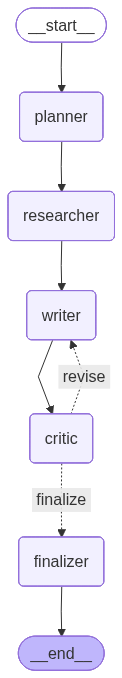

In [9]:
#visualize graph
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization skipped:", e)


##Run the Multi-Agent Graph

In [10]:
initial_state: GraphState = {
    "question": question,
    "plan": None,
    "research_notes": [],
    "draft": None,
    "critique": None,
    "iteration": 0,
    "max_iterations": 2,
}



result = app.invoke(initial_state)
print(result["draft"])


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for op

Final Answer:
{
  "summary": "In 2026, a startup should consider the following when deciding between open-source LLMs and closed models: open-source LLMs offer cost savings but require significant resources for training and maintenance, while closed models come with a cost but often include additional features and support.",
  "pros_open_source_llms": "Cost savings: Open-source LLMs are generally free to use, which can be a significant advantage for startups with limited budgets.",
  "cons_open_source_llms": "Training and maintenance: Open-source LLMs require significant resources for training and maintenance, which can be a challenge for startups with limited resources.",
  "pros_closed_models": "Additional features and support: Closed models often come with additional features and support, which can be a major advantage for startups looking to streamline their operations and focus on their core business.",
  "cons_closed_models": "Cost: Closed models may come with a licensing fee or 

# compare single vs multi agents

In [11]:
def run_comparison(question: str):
    print("====== Single Agent ======")
    print(single_agent_answer(question))
    print("\n\n====== Multi-Agent (LangGraph) ======")
    initial_state: GraphState = {
        "question": question,
        "plan": None,
        "research_notes": [],
        "draft": None,
        "critique": None,
        "iteration": 0,
        "max_iterations": 2,
    }
    result = app.invoke(initial_state)
    print(result["draft"])

run_comparison("Should I build my AI product on open-source LLMs (self-hosted) or closed APIs in 2026 if I handle sensitive customer data?")


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


====== Single Agent ======


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are a helpful AI.
Task: Provide a well-reasoned recommendation to the user question.
Rules:
- Make your best effort without browsing the web.
- Be structured:
  Summary
  Pros
  Cons
  Recommendation
  Risks
  Confidence (0-100).


User Question:
Should I build my AI product on open-source LLMs (self-hosted) or closed APIs in 2026 if I handle sensitive customer data?

Assistant:
Summary:
The decision between using open-source Language Models (LLMs) for your AI product, self-hosted, or closed APIs, hinges on several factors, particularly when handling sensitive customer data.

Pros of Open-Source LLMs:
1. Customizability: Open-source models can be customized to meet specific business needs, providing more control over the product.
2. Cost-effective: Open-source models do not require ongoing subscription fees, making them a cost-effective option.
3. Transparency: Users have access to the model's source code, allowing for a better understanding of how the model processes data.

Cons o

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

If critique exists, incorporate fixes:

If the critique identifies any missing points or issues, they should be addressed in the plan by adding or modifying steps as necessary. The fix instructions provided in the critique should be followed to ensure the plan is as accurate and complete as possible. The confidence level may also be adjusted based on the severity of the critique and the extent of the necessary changes.


#Lets try few questions

In [12]:
questions = [
    "Should a startup use open-source LLMs or closed models in 2026? Consider cost, speed, privacy, and reliability.",
    "We are in healthcare. Which approach is safer for compliance and auditability?",
    "We need extremely low latency on-device. What should we choose and why?",
]

for q in questions:
    _ = single_agent_answer(q)
    _ = app.invoke({
        "question": q,
        "plan": None,
        "research_notes": [],
        "draft": None,
        "critique": None,
        "iteration": 0,
        "max_iterations": 1,
    })  # traced

print("Done. Open LangSmith project to compare traces and outputs.")


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:2 for op

Done. Open LangSmith project to compare traces and outputs.
